In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv("/content/breast-cancer-wisconsin.data", header=None)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]
le = LabelEncoder()
X = X.apply(le.fit_transform)
y = le.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Convert regression output to class
y_pred_class = np.round(y_pred).astype(int)

acc = accuracy_score(y_test, y_pred_class)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, y_pred_class)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.9523809523809523
Confusion Matrix:
[[140   3   0]
 [  6  60   1]
 [  0   0   0]]


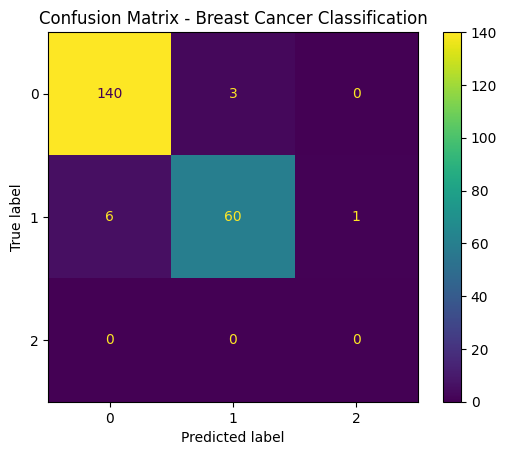

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_class)
plt.title("Confusion Matrix - Breast Cancer Classification")
plt.show()